# Mérési notebook
---
# **4. mérési fázis**. Saját modellek fejlesztése.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 2. lépés: saját modellek teljes tanítás utáni tesztelése.

---

Saját modell tesztelése. ResNet18 modern fejrésszel.

(3 különböző fejrész tesztelése a cél)

✅ 0. Telepítés és beállítások

✅ 1. Drive csatolás + ZIP kicsomagolás

In [ ]:
# 🧰 Alapcsomagok
!pip install -q timm scikit-learn scikit-plot

# 🖼️ matplotlib + seaborn (ha valami hiányzik)
!pip install -q matplotlib seaborn

# 📁 Google Drive csatolása
from google.colab import drive
drive.mount('/content/drive')

# 📦 Kitömörítés, ha szükséges
import zipfile, os

diploma_path = "/content/drive/MyDrive/diplomamunka"
dataset_zip = os.path.join(diploma_path, "imagenet_splitted_db.zip")
dataset_dir = "/content/imagenet_splitted_db"

if not os.path.exists(dataset_dir):
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Kicsomagolva:", dataset_dir)
else:
    print("✅ Már ki van csomagolva:", dataset_dir)

# ⚙️ GPU ellenőrzés
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Aktív eszköz: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 114.7 MB/s eta 0:00:00
Mounted at /content/drive
✅ Kicsomagolva: /content/imagenet_splitted_db
📡 Aktív eszköz: cuda


Mappa pontosítás

🧠 2. ResNet18 modell betöltése

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from copy import deepcopy

# Eszköz beállítása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Előre betanított ResNet18 letöltése ImageNet1k súlyokkal
resnet18_base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Általános paraméterek
num_classes = 114
in_features = resnet18_base.fc.in_features  # 512 a ResNet18 esetén


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


🧪 3. Három különböző osztályozó fej definiálása

In [ ]:
# Baseline fej: gyors, stabil tanulás
baseline_head = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Deep fej: mélyebb FC architektúra
deep_head = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Hybrid fej: külön osztályban definiáljuk
class ResNet18HybridHead(nn.Module):
    def __init__(self, num_classes=114):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.avgpool = nn.Identity()
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),     # ez került előre!
            nn.LayerNorm([256, 1, 1]),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        return self.head(x)

🔍 4. A három teljes modell példányosítása

In [ ]:
# 1. Baseline modell
resnet18_baseline = deepcopy(resnet18_base)
resnet18_baseline.fc = baseline_head
resnet18_baseline = resnet18_baseline.to(device)

# 2. Deep modell
resnet18_deep = deepcopy(resnet18_base)
resnet18_deep.fc = deep_head
resnet18_deep = resnet18_deep.to(device)

# 3. Hybrid modell – teljes saját forward metódussal
resnet18_hybrid = ResNet18HybridHead(num_classes=num_classes)
resnet18_hybrid = resnet18_hybrid.to(device)


🧠 5. A tanító föggvény

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 📦 Könyvtárak ---
root_dir = "/content/imagenet_splitted_db"
batch_size = 64
image_size = 224

# --- 🧪 Transzformációk ---
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet statisztikák
                         std=[0.229, 0.224, 0.225])
])

# --- 📚 Datasetek betöltése ---
train_dataset = datasets.ImageFolder(root=f"{root_dir}/train", transform=transform)
val_dataset   = datasets.ImageFolder(root=f"{root_dir}/val", transform=transform)
test_dataset  = datasets.ImageFolder(root=f"{root_dir}/test", transform=transform)

# --- 🚚 Adatbetöltők ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- 📌 Osztálynevek elmentése ha szükséges ---
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"📊 Osztályok száma: {num_classes}")


📊 Osztályok száma: 114


In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

import matplotlib.pyplot as plt

def train_model(model, model_name, num_epochs=10, plot_results=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - val"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 [{model_name}] Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    # --- 🎨 Tanulási görbék ---
    if plot_results:
        plt.figure(figsize=(12, 4))

        # Loss
        plt.subplot(1, 2, 1)
        plt.plot(train_loss_hist, label="Train Loss")
        plt.plot(val_loss_hist, label="Val Loss")
        plt.title(f"{model_name} – Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(train_acc_hist, label="Train Acc")
        plt.plot(val_acc_hist, label="Val Acc")
        plt.title(f"{model_name} – Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist

🧠 6A. ResNet18 + Baseline fej – teljes újratanítás

[ResNet18 + Baseline] Epoch 1/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.88it/s]


📊 [ResNet18 + Baseline] Epoch 1: Train loss=1.8577, acc=0.5388 | Val loss=1.3439, acc=0.6352


[ResNet18 + Baseline] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.84it/s]


📊 [ResNet18 + Baseline] Epoch 2: Train loss=1.1849, acc=0.6784 | Val loss=1.1789, acc=0.6764


[ResNet18 + Baseline] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.93it/s]


...

📊 [ResNet18 + Baseline] Epoch 8: Train loss=0.2175, acc=0.9348 | Val loss=1.3409, acc=0.7261


[ResNet18 + Baseline] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.74it/s]


📊 [ResNet18 + Baseline] Epoch 9: Train loss=0.1915, acc=0.9436 | Val loss=1.4243, acc=0.7273


[ResNet18 + Baseline] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.99it/s]


📊 [ResNet18 + Baseline] Epoch 10: Train loss=0.1688, acc=0.9510 | Val loss=1.4965, acc=0.7213


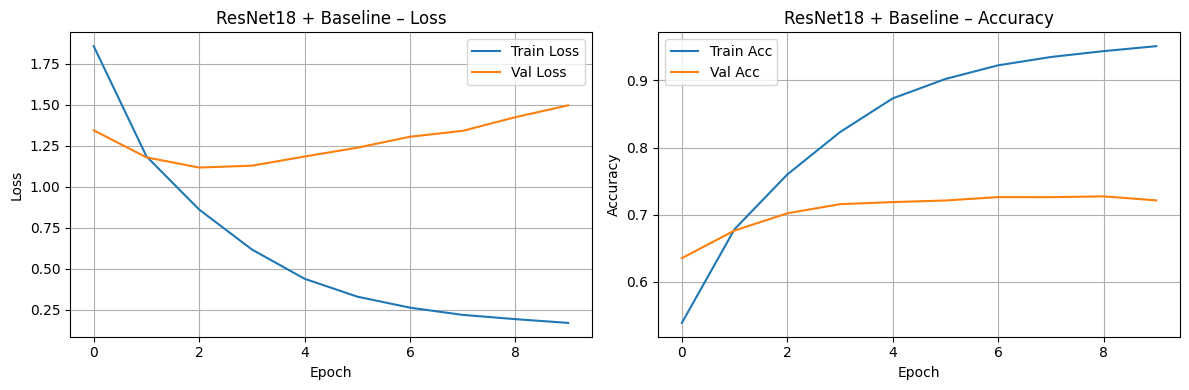

In [ ]:
# 🚀 Tanítás: Baseline
model_baseline, loss_baseline, val_loss_baseline, acc_baseline, val_acc_baseline = train_model(
    resnet18_baseline, model_name="ResNet18 + Baseline", num_epochs=10
)

🧪 6B. ResNet18 + Deep fej – teljes újratanítás

[ResNet18 + Deep] Epoch 1/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.87it/s]


📊 [ResNet18 + Deep] Epoch 1: Train loss=2.0445, acc=0.4984 | Val loss=1.4451, acc=0.6133


[ResNet18 + Deep] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.87it/s]


📊 [ResNet18 + Deep] Epoch 2: Train loss=1.3273, acc=0.6444 | Val loss=1.2521, acc=0.6615


[ResNet18 + Deep] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.69it/s]


...

📊 [ResNet18 + Deep] Epoch 8: Train loss=0.2820, acc=0.9164 | Val loss=1.4481, acc=0.7217


[ResNet18 + Deep] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.63it/s]


📊 [ResNet18 + Deep] Epoch 9: Train loss=0.2400, acc=0.9293 | Val loss=1.5396, acc=0.7178


[ResNet18 + Deep] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.90it/s]


📊 [ResNet18 + Deep] Epoch 10: Train loss=0.2150, acc=0.9364 | Val loss=1.5620, acc=0.7236


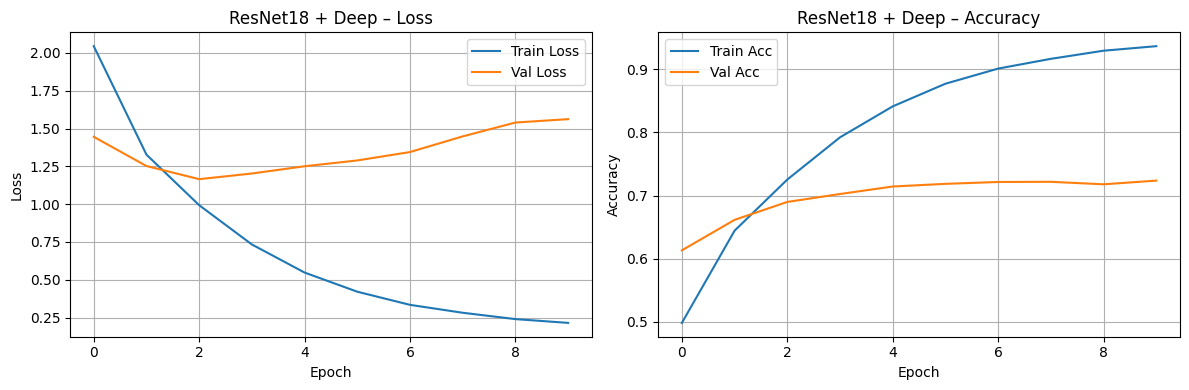

In [ ]:
# 🚀 Tanítás: Deep fej
model_deep, loss_deep, val_loss_deep, acc_deep, val_acc_deep = train_model(
    resnet18_deep, model_name="ResNet18 + Deep", num_epochs=10
)

🧬 6C. ResNet18 + Hybrid fej – teljes újratanítás

[ResNet18 + Hybrid] Epoch 1/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.45it/s]


📊 [ResNet18 + Hybrid] Epoch 1: Train loss=1.7667, acc=0.5714 | Val loss=1.3361, acc=0.6410


[ResNet18 + Hybrid] Epoch 2/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.49it/s]


📊 [ResNet18 + Hybrid] Epoch 2: Train loss=1.0394, acc=0.7168 | Val loss=1.1237, acc=0.6920


[ResNet18 + Hybrid] Epoch 3/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.22it/s]


...

📊 [ResNet18 + Hybrid] Epoch 8: Train loss=0.1572, acc=0.9546 | Val loss=1.3195, acc=0.7267


[ResNet18 + Hybrid] Epoch 9/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.45it/s]


📊 [ResNet18 + Hybrid] Epoch 9: Train loss=0.1398, acc=0.9594 | Val loss=1.3501, acc=0.7233


[ResNet18 + Hybrid] Epoch 10/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.40it/s]


📊 [ResNet18 + Hybrid] Epoch 10: Train loss=0.1249, acc=0.9636 | Val loss=1.4221, acc=0.7256


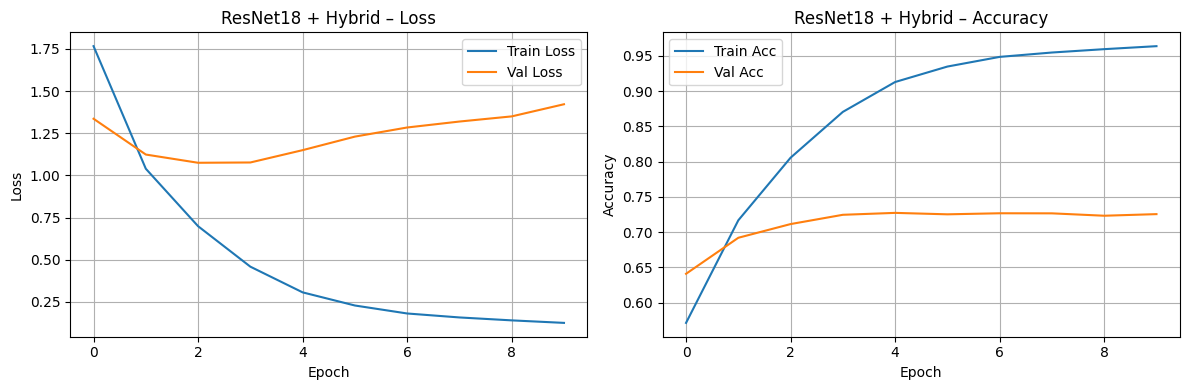

In [ ]:
# 🚀 Tanítás: Hybrid fej
model_hybrid, loss_hybrid, val_loss_hybrid, acc_hybrid, val_acc_hybrid = train_model(
    resnet18_hybrid, model_name="ResNet18 + Hybrid", num_epochs=10
)

📊 6D. Összesítő grafikon a végén – külön blokkban

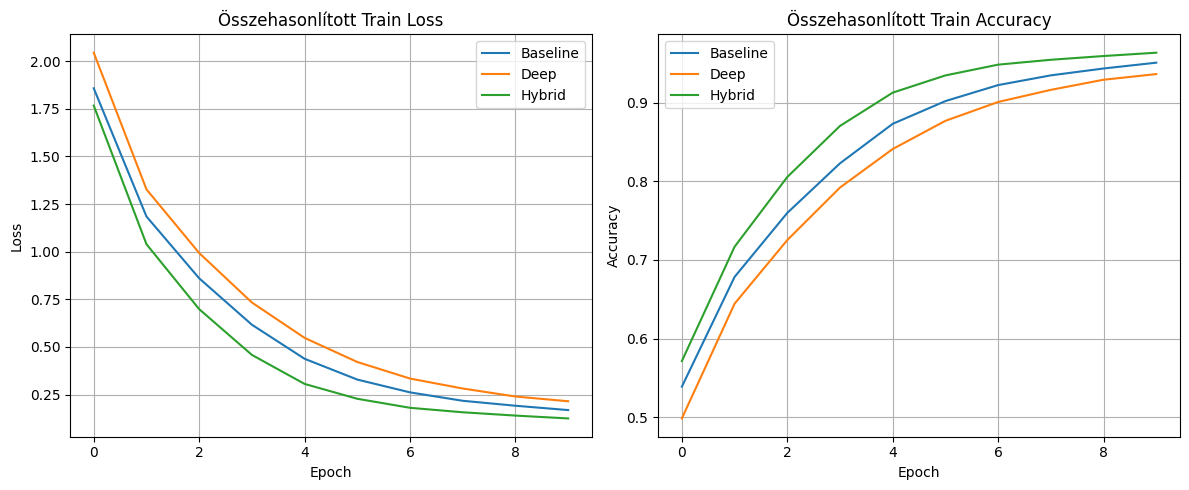

In [ ]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(loss_baseline, label="Baseline")
plt.plot(loss_deep, label="Deep")
plt.plot(loss_hybrid, label="Hybrid")
plt.title("Összehasonlított Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_baseline, label="Baseline")
plt.plot(acc_deep, label="Deep")
plt.plot(acc_hybrid, label="Hybrid")
plt.title("Összehasonlított Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


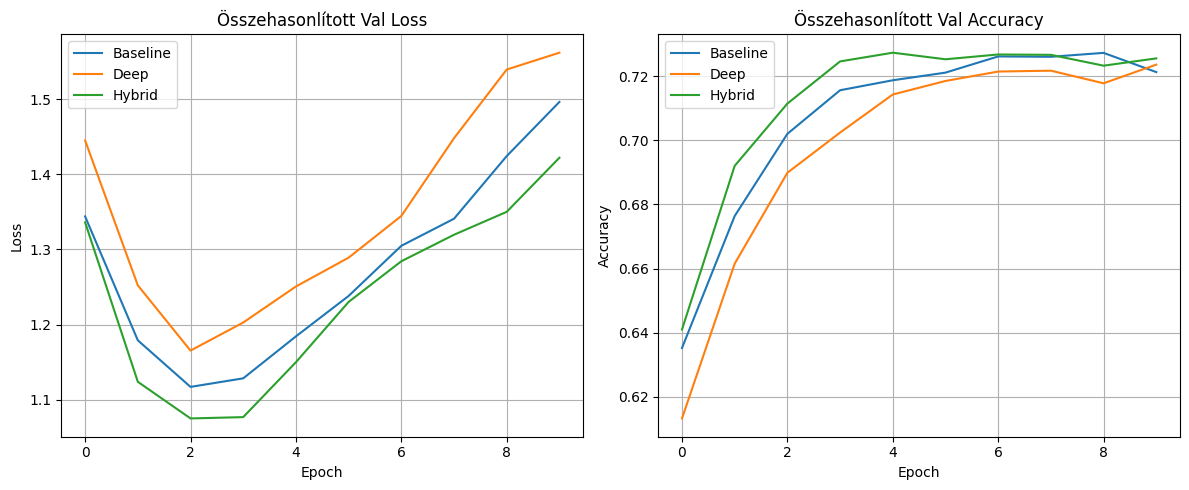

In [ ]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(val_loss_baseline, label="Baseline")
plt.plot(val_loss_deep, label="Deep")
plt.plot(val_loss_hybrid, label="Hybrid")
plt.title("Összehasonlított Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_acc_baseline, label="Baseline")
plt.plot(val_acc_deep, label="Deep")
plt.plot(val_acc_hybrid, label="Hybrid")
plt.title("Összehasonlított Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


🔍 6E. A három teljes modell lementése

In [ ]:
# --- Modellmentés (állapotdict mentése) ---

save_dir = "trained_models"
os.makedirs(save_dir, exist_ok=True)

torch.save(resnet18_baseline.state_dict(), f"{save_dir}/resnet18_baseline.pth")
torch.save(resnet18_deep.state_dict(), f"{save_dir}/resnet18_deep.pth")
torch.save(resnet18_hybrid.state_dict(), f"{save_dir}/resnet18_hybrid.pth")

print("✅ Modellek sikeresen elmentve:")
print(f"📦 {save_dir}/resnet18_baseline.pth")
print(f"📦 {save_dir}/resnet18_deep.pth")
print(f"📦 {save_dir}/resnet18_hybrid.pth")


✅ Modellek sikeresen elmentve:
📦 trained_models/resnet18_baseline.pth
📦 trained_models/resnet18_deep.pth
📦 trained_models/resnet18_hybrid.pth


🚀 7. Inferencia – 1. fázis: előtanítás nélküli teljesítmény a három modellen

Minden modellre külön blokkban végezzük el az inferenciát a `test_loader` segítségével.

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import time

# 🔄 Transzformációk (ugyanaz, mint eddig)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 📁 Teszthalmaz betöltése
test_dir = "/content/imagenet_splitted_db/test"
test_dataset = ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# ✅ Használt osztályok (fontos a mapping-hez)
class_names = test_dataset.classes
num_classes = len(class_names)

📦 7.1 Inferencia – ResNet18 + baseline fej

In [ ]:
resnet18_baseline.eval()
all_preds, all_labels, all_probs = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Baseline modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_baseline(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time_baseline = time.time() - start_time


🔍 Baseline modell – tesztelés: 100%|██████████| 284/284 [00:18<00:00, 15.32it/s]


📦 7.2 Inferencia – ResNet18 + deep fej

In [ ]:
resnet18_deep.eval()
all_preds_d, all_labels_d, all_probs_d = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Deep modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_deep(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds_d.extend(preds.cpu().numpy())
        all_labels_d.extend(labels.cpu().numpy())
        all_probs_d.extend(probs.cpu().numpy())

inference_time_deep = time.time() - start_time


🔍 Deep modell – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 17.75it/s]


📦 7.3 Inferencia – ResNet18 + hybrid fej

In [ ]:
resnet18_hybrid.eval()
all_preds_h, all_labels_h, all_probs_h = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_hybrid(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds_h.extend(preds.cpu().numpy())
        all_labels_h.extend(labels.cpu().numpy())
        all_probs_h.extend(probs.cpu().numpy())

inference_time_hybrid = time.time() - start_time


🔍 Hybrid modell – tesztelés: 100%|██████████| 284/284 [00:16<00:00, 17.61it/s]


📊 8. Metrikák számítása – mindhárom saját modellre (baseline, deep, hybrid)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    top_k_accuracy_score, confusion_matrix, classification_report
)

def evaluate_metrics(y_true, y_pred, y_probs, model_name, inference_time):
    top1 = accuracy_score(y_true, y_pred)
    top5 = top_k_accuracy_score(y_true, y_probs, k=5, labels=range(len(class_names)))
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n🔍 Vizsgálat eredményei ({model_name}):")
    print(f"✅ Top-1 Accuracy:  {top1:.4f}")
    print(f"✅ Top-5 Accuracy:  {top5:.4f}")
    print(f"🎯 Precision:       {precision:.4f}")
    print(f"🎯 Recall:          {recall:.4f}")
    print(f"🎯 F1-score:        {f1:.4f}")
    print(f"⏱️ Inference time:  {inference_time:.2f} sec")

    return {
        "top1": top1,
        "top5": top5,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "time": inference_time
    }

📈 Metrikák meghívása a három modellhez

In [ ]:
metrics_baseline = evaluate_metrics(
    np.array(all_labels), np.array(all_preds), np.array(all_probs),
    "ResNet18 + Baseline fej", inference_time_baseline
)

metrics_deep = evaluate_metrics(
    np.array(all_labels_d), np.array(all_preds_d), np.array(all_probs_d),
    "ResNet18 + Deep fej", inference_time_deep
)

metrics_hybrid = evaluate_metrics(
    np.array(all_labels_h), np.array(all_preds_h), np.array(all_probs_h),
    "ResNet18 + Hybrid fej", inference_time_hybrid
)



🔍 Vizsgálat eredményei (ResNet18 + Baseline fej):
✅ Top-1 Accuracy:  0.7303
✅ Top-5 Accuracy:  0.9099
🎯 Precision:       0.6777
🎯 Recall:          0.6490
🎯 F1-score:        0.6568
⏱️ Inference time:  18.54 sec

🔍 Vizsgálat eredményei (ResNet18 + Deep fej):
✅ Top-1 Accuracy:  0.7247
✅ Top-5 Accuracy:  0.9000
🎯 Precision:       0.6673
🎯 Recall:          0.6336
🎯 F1-score:        0.6455
⏱️ Inference time:  16.01 sec

🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej):
✅ Top-1 Accuracy:  0.7276
✅ Top-5 Accuracy:  0.9074
🎯 Precision:       0.6828
🎯 Recall:          0.6369
🎯 F1-score:        0.6536
⏱️ Inference time:  16.13 sec


🧩 9. Confusion Matrix – 3 modell, klasszikus ábrázolással (matplotlib + seaborn)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

🟦 Baseline modell Confusion Matrix

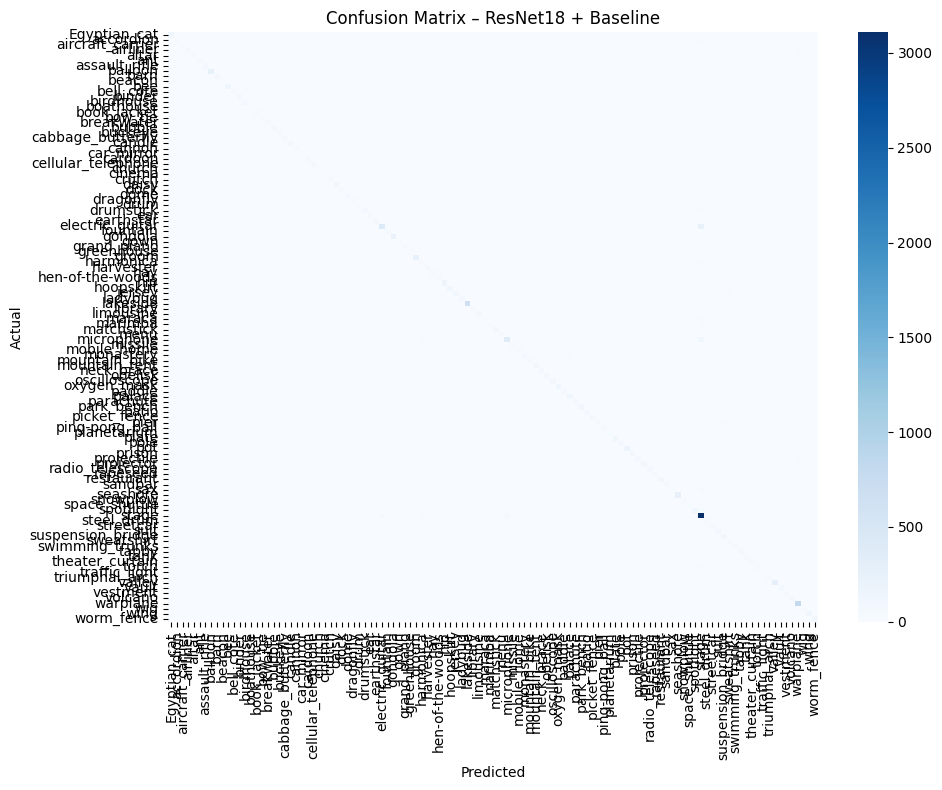

In [ ]:
plot_confusion_matrix(all_labels, all_preds, class_names, "Confusion Matrix – ResNet18 + Baseline")


🟩 Deep modell Confusion Matrix

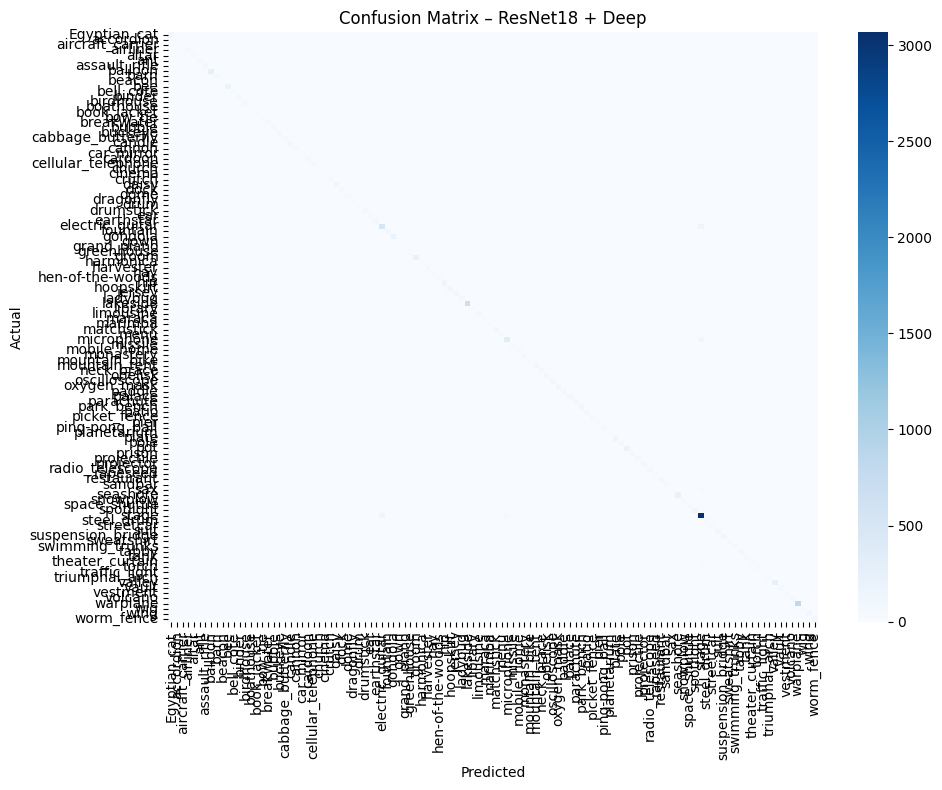

In [ ]:
plot_confusion_matrix(all_labels_d, all_preds_d, class_names, "Confusion Matrix – ResNet18 + Deep")


🟨 Hybrid modell Confusion Matrix

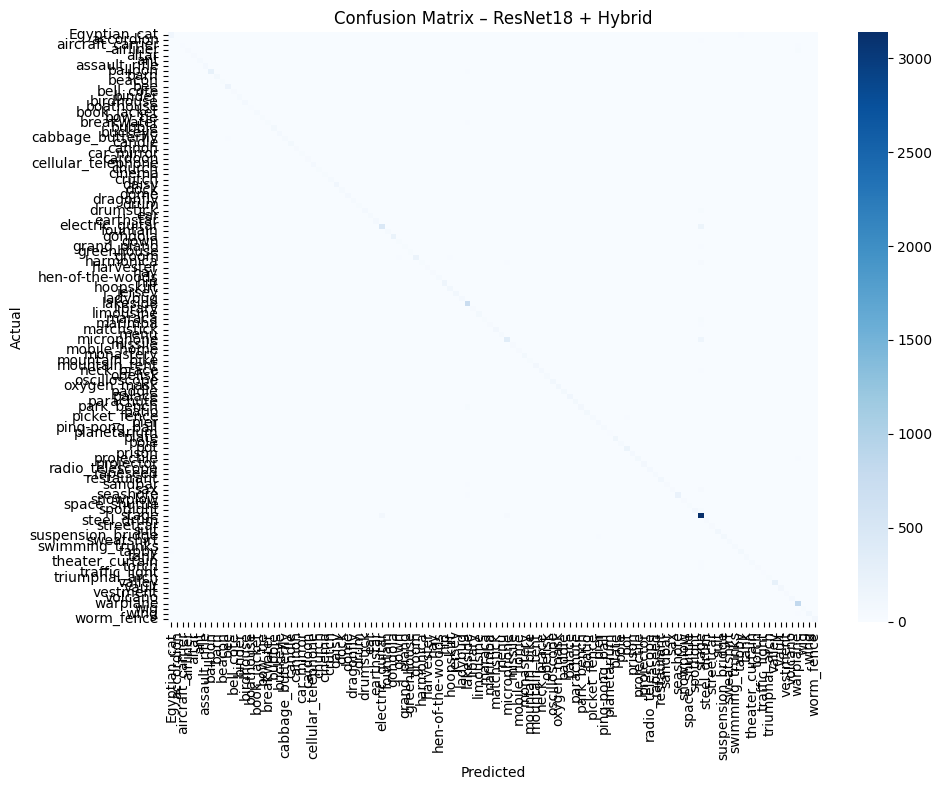

In [ ]:
plot_confusion_matrix(all_labels_h, all_preds_h, class_names, "Confusion Matrix – ResNet18 + Hybrid")


🎨 10. Szebb Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(18, 16))  # Nagyobb ábra, hogy elférjen minden
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title, fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()


🟦 Baseline modell (szépített)

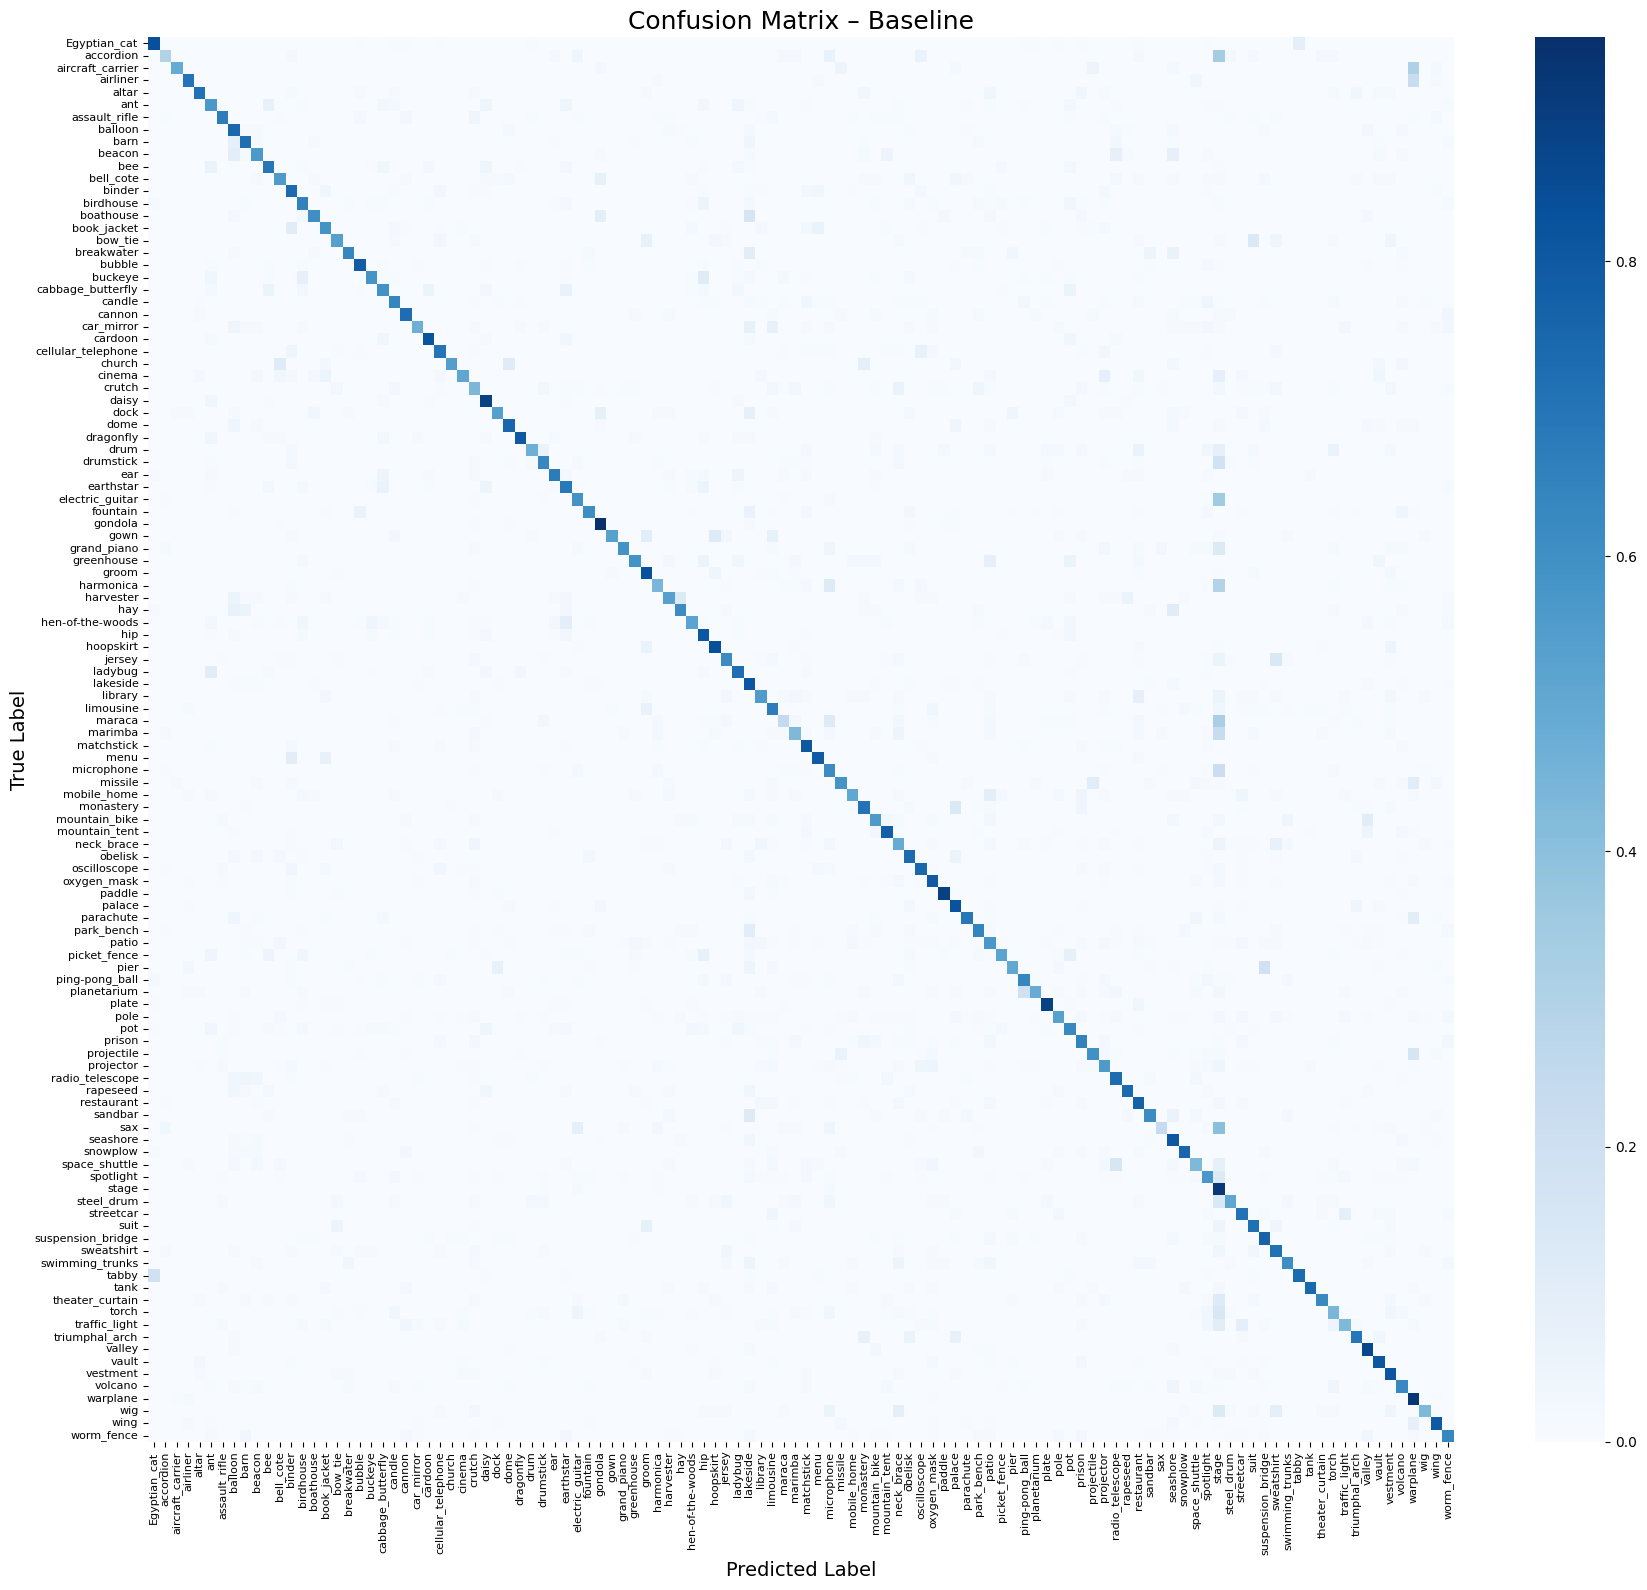

In [ ]:
plot_confusion_matrix_pretty(all_labels, all_preds, class_names, "Confusion Matrix – Baseline")


🟩 Deep modell (szépített)

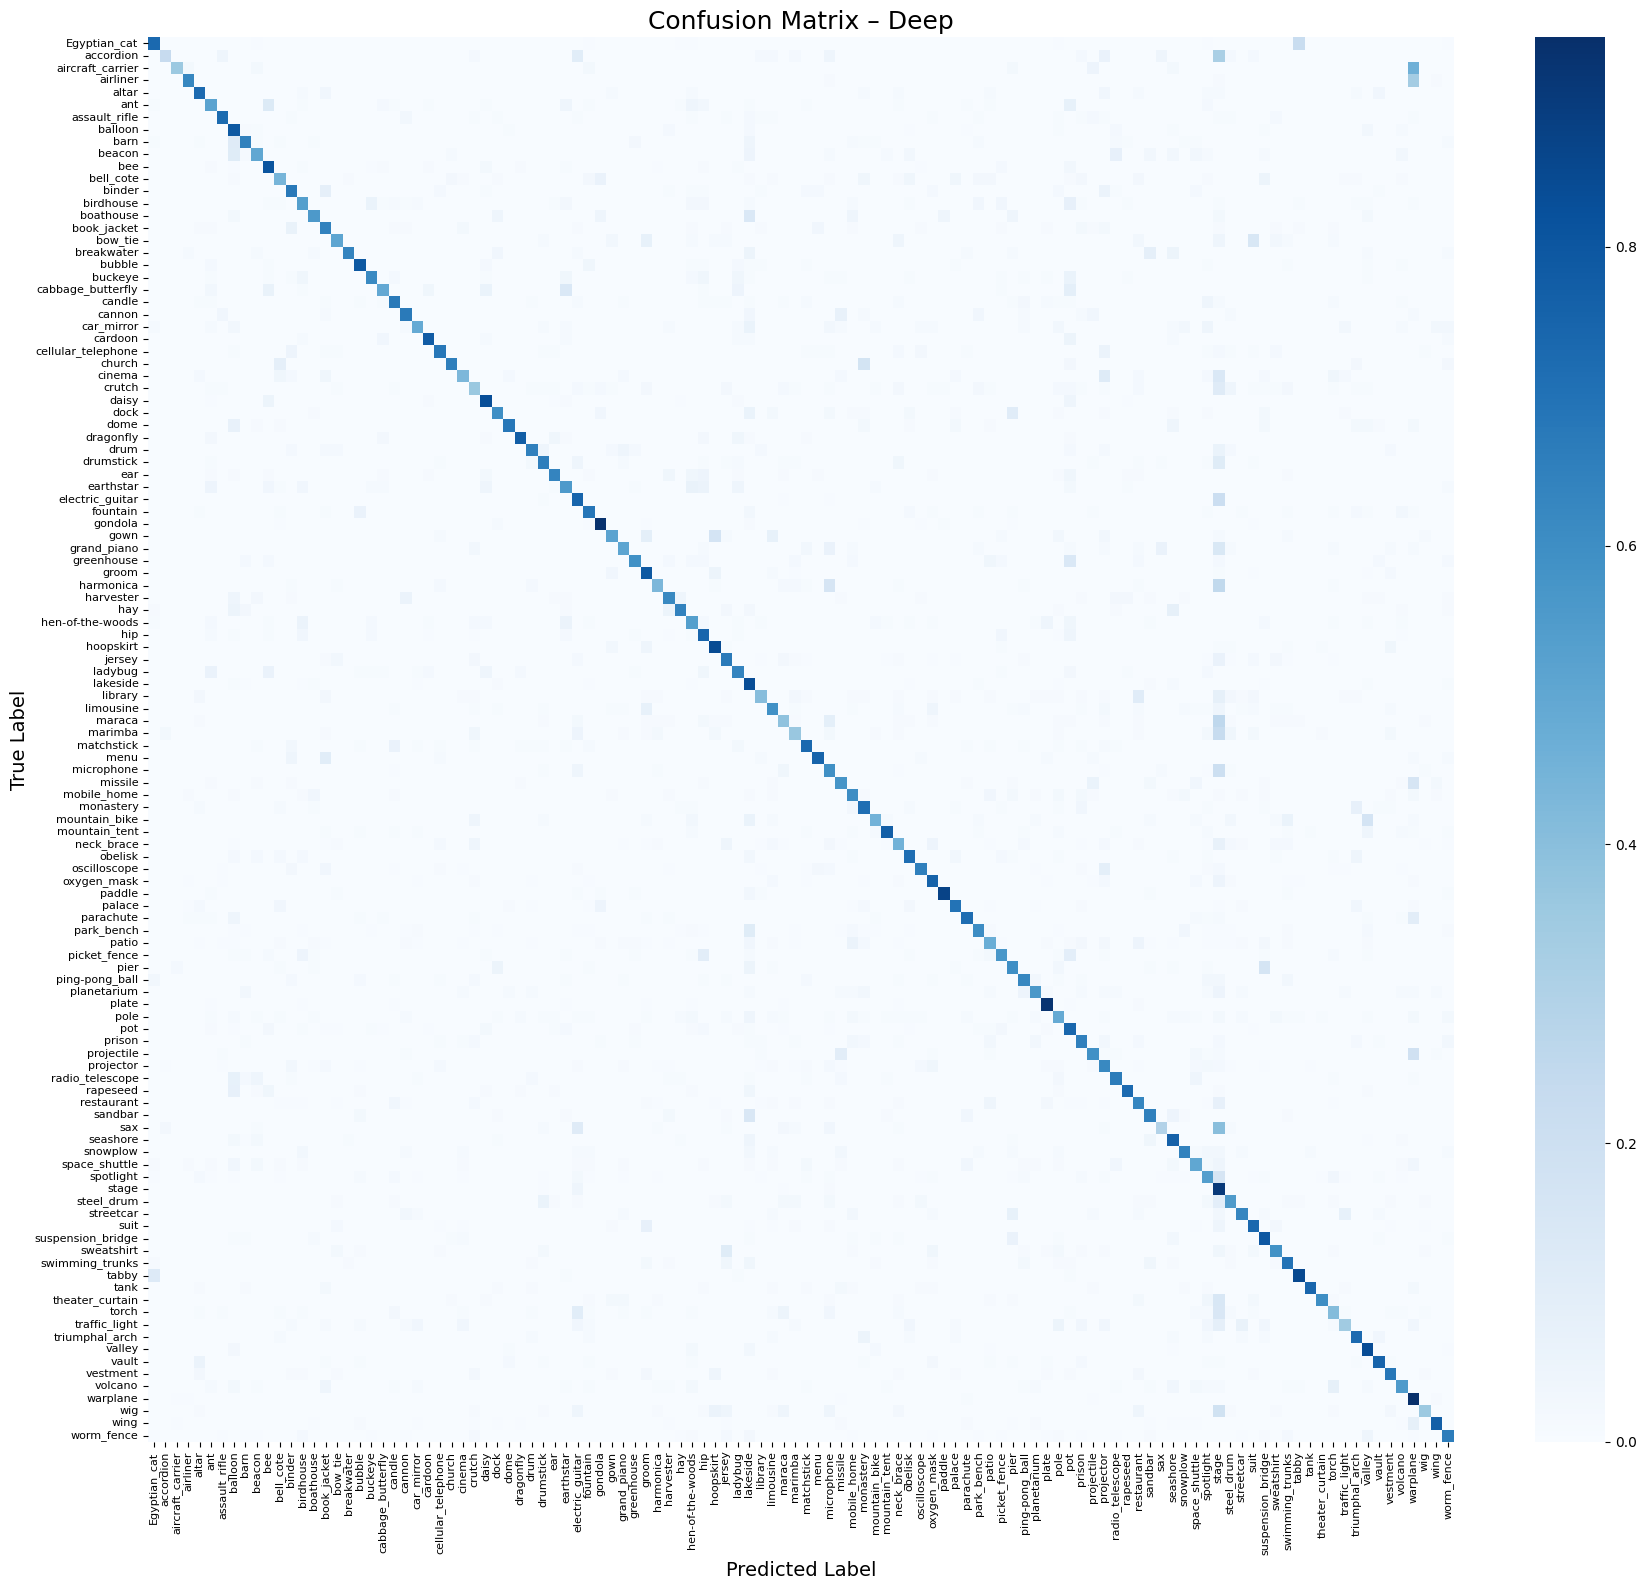

In [ ]:
plot_confusion_matrix_pretty(all_labels_d, all_preds_d, class_names, "Confusion Matrix – Deep")


🟨 Hybrid modell (szépített)

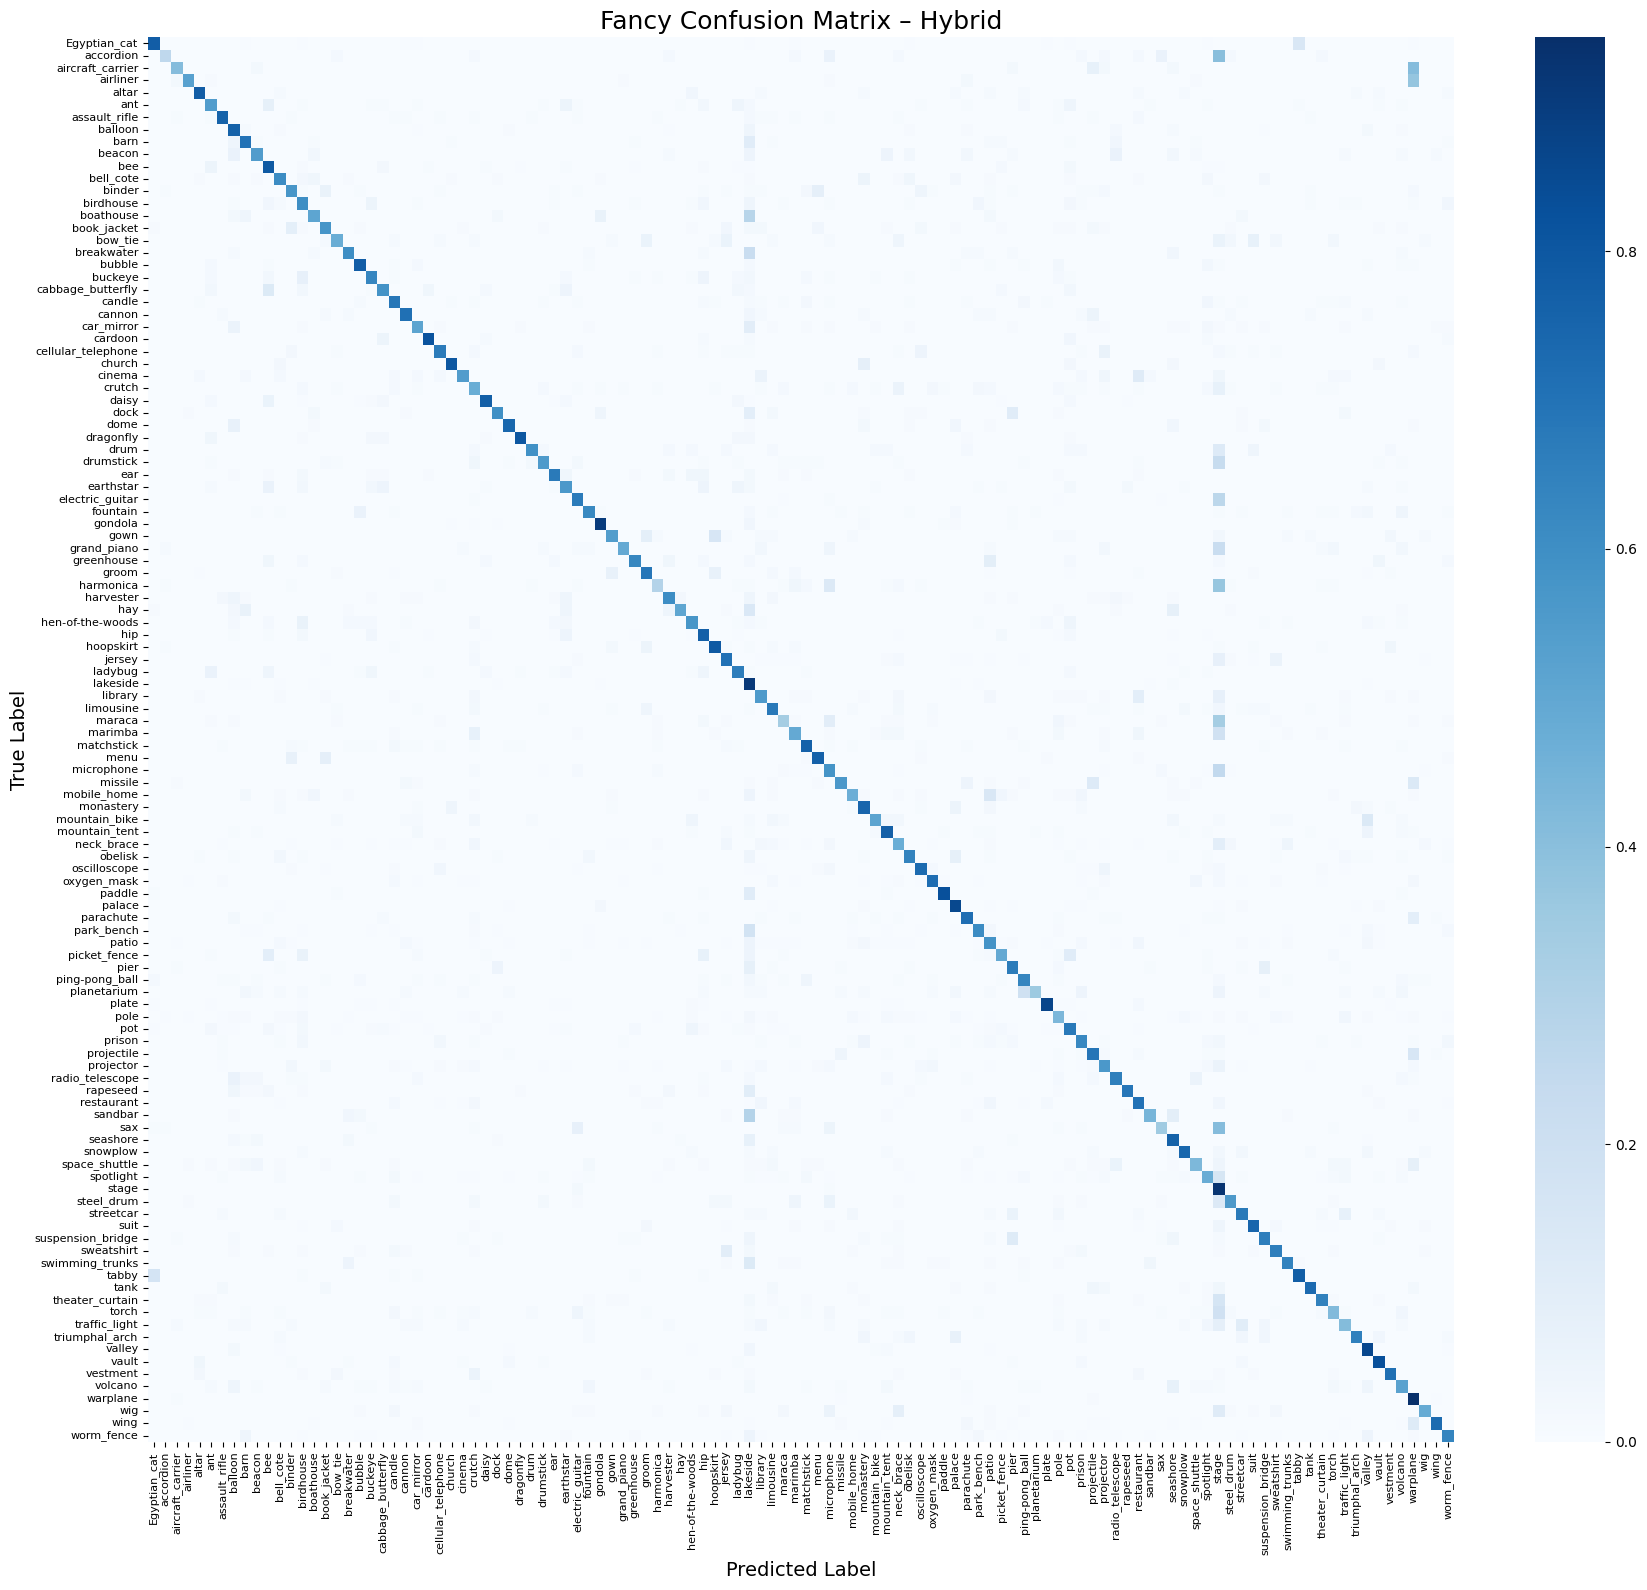

In [ ]:
plot_confusion_matrix_pretty(all_labels_h, all_preds_h, class_names, "Fancy Confusion Matrix – Hybrid")


✅ 11. Részletes osztályonkénti metrikák (Precision / Recall / F1) és CSV export – 3 modellhez

Az alábbi kód mindhárom saját ResNet18 alapú modellre elkészíti:
- osztályonkénti precízió, recall, F1-score értékeket
- képernyőre írja a részletes jelentést
- CSV-fájlba menti jól azonosítható névvel

🛠️ Közös függvény


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def export_classification_report(y_true, y_pred, class_names, model_name_slug):
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    df = pd.DataFrame(report_dict).transpose()
    csv_filename = f"stage1_class_report_{model_name_slug}.csv"
    df.to_csv(csv_filename, index=True)
    print(f"\n📄 Exportálva: {csv_filename}")
    return df

🟦 Baseline modell

In [ ]:
print("📋 Baseline modell – osztályonkénti metrikák:\n")
df_baseline = export_classification_report(all_labels, all_preds, class_names, "resnet18_baseline")
display(df_baseline.head())


📋 Baseline modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_baseline.csv


,precision,recall,f1-score,support
Egyptian_cat,0.801325,0.834483,0.817568,145.0
accordion,0.424242,0.297872,0.350000,47.0
aircraft_carrier,0.633333,0.487179,0.550725,39.0
airliner,0.674699,0.700000,0.687117,80.0
altar,0.792453,0.711864,0.750000,59.0


🟩 Deep modell

In [ ]:
print("📋 Deep modell – osztályonkénti metrikák:\n")
df_deep = export_classification_report(all_labels_d, all_preds_d, class_names, "resnet18_deep")
display(df_deep.head())


📋 Deep modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_deep.csv


,precision,recall,f1-score,support
Egyptian_cat,0.796992,0.731034,0.762590,145.0
accordion,0.478261,0.234043,0.314286,47.0
aircraft_carrier,0.636364,0.358974,0.459016,39.0
airliner,0.781250,0.625000,0.694444,80.0
altar,0.558442,0.728814,0.632353,59.0


🟨 Hybrid modell

In [ ]:
print("📋 Hybrid modell – osztályonkénti metrikák:\n")
df_hybrid = export_classification_report(all_labels_h, all_preds_h, class_names, "resnet18_hybrid")
display(df_hybrid.head())


📋 Hybrid modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_hybrid.csv


,precision,recall,f1-score,support
Egyptian_cat,0.801418,0.779310,0.790210,145.0
accordion,0.600000,0.255319,0.358209,47.0
aircraft_carrier,0.470588,0.410256,0.438356,39.0
airliner,0.840000,0.525000,0.646154,80.0
altar,0.754098,0.779661,0.766667,59.0


🔍 12. A 10 leggyengébben teljesítő osztály (F1-score alapján)

A következő blokk mindhárom modell osztályonkénti statisztikájából kiválogatja a **Top 10 leggyengébben teljesítő osztályt** az F1-score érték alapján.  
Ez segít azonosítani azokat a kategóriákat, amelyekre a modellek a legbizonytalanabbak voltak.


In [ ]:
def print_worst_classes(df, model_name, top_n=10):
    df_filtered = df.iloc[:-3]  # support, accuracy, macro avg sorokat elhagyjuk
    worst = df_filtered.sort_values("f1-score").head(top_n)
    print(f"\n📉 {model_name} – Top {top_n} leggyengébb osztály (F1-score alapján):\n")
    display(worst[["precision", "recall", "f1-score"]])

🟦 Baseline modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_baseline, "ResNet18 + Baseline fej")



📉 ResNet18 + Baseline fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
maraca,0.423077,0.244444,0.309859
sax,0.600000,0.241071,0.343949
accordion,0.424242,0.297872,0.350000
crutch,0.383333,0.438095,0.408889
marimba,0.435897,0.430380,0.433121
harmonica,0.431373,0.440000,0.435644
space_shuttle,0.473684,0.428571,0.450000
traffic_light,0.520833,0.431034,0.471698
torch,0.520408,0.439655,0.476636
neck_brace,0.468531,0.489051,0.478571


🟩 Deep modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_deep, "ResNet18 + Deep fej")



📉 ResNet18 + Deep fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.478261,0.234043,0.314286
maraca,0.321101,0.388889,0.351759
sax,0.568966,0.294643,0.388235
crutch,0.441860,0.361905,0.397906
traffic_light,0.526316,0.344828,0.416667
marimba,0.483333,0.367089,0.417266
wig,0.595238,0.357143,0.446429
torch,0.505263,0.413793,0.454976
aircraft_carrier,0.636364,0.358974,0.459016
cinema,0.511628,0.431373,0.468085


🟨 Hybrid modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_hybrid, "ResNet18 + Hybrid fej")


📉 ResNet18 + Hybrid fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
harmonica,0.460317,0.290000,0.355828
accordion,0.600000,0.255319,0.358209
maraca,0.422535,0.333333,0.372671
traffic_light,0.369231,0.413793,0.390244
crutch,0.337838,0.476190,0.395257
sax,0.534247,0.348214,0.421622
aircraft_carrier,0.470588,0.410256,0.438356
marimba,0.419355,0.493671,0.453488
pole,0.491667,0.433824,0.460938
torch,0.544444,0.422414,0.475728


✅ x. GPU memóriahasználat, batch sebesség statisztika

In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.49 GB
💾 GPU memória (használt):  0.31 GB
